In [155]:
#Importing libraries...
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import math

In [156]:
#Device...
Device = torch.device("cuda")

In [157]:
#Embedding layer...
class EmbeddingLayer(nn.Module):
    def __init__(self,vocab_size,embedd_dim):
        super().__init__()

        self.EL = nn.Embedding(num_embeddings = vocab_size,
                               embedding_dim = embedd_dim)

    def forward(self,datapoints):
        out = self.EL(datapoints)
        return out

In [158]:
#Projection layer...
class ProjectionLayer(nn.Module):
    def __init__(self,in_features,embedd_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(in_features = in_features,
                      out_features = embedd_dim),
            nn.ReLU(),

            nn.Linear(in_features = embedd_dim,
                      out_features = embedd_dim)
        )

    def forward(self,datapoints):
        out = self.network(datapoints)
        return out

In [159]:
#PositionalEncoding Layer...
class PosEncoding(nn.Module):
  def __init__(self,embedd_dim,max_len):
    super().__init__()

    pe = torch.zeros(max_len,embedd_dim)
    positon = torch.arange(0,max_len).unsqueeze(1)

    div_term = torch.exp(
            torch.arange(0,embedd_dim,2) * (-math.log(10000.0) / embedd_dim)
        )

    pe[:,0::2] = torch.sin(positon * div_term)
    pe[:,1::2] = torch.cos(positon * div_term)

    pe = pe.unsqueeze(0)
    self.register_buffer("pe", pe)

  def forward(self,x):
        T = x.size(1)
        return x + self.pe[:,:T]

In [160]:
#EncoderStack...
class EncoderStack(nn.Module):
    def __init__(self,embedd_dim,heads,dropout,Layers):
        super().__init__()

        EncoderLayer = nn.TransformerEncoderLayer(d_model = embedd_dim,
                                                  nhead = heads,
                                                  dropout = dropout,
                                                  batch_first = True,
                                                  )

        self.EncoderS = nn.TransformerEncoder(encoder_layer = EncoderLayer,
                                              num_layers = Layers)

    def forward(self,embeddings):
        mask = torch.triu(torch.ones(embeddings.size(1),embeddings.size(1),device = Device),diagonal = 1)
        mask = mask.masked_fill_(mask == 1,float("-inf"))

        out = self.EncoderS(embeddings,mask = mask)
        return out

In [161]:
#Head layer...
class Head(nn.Module):
    def __init__(self,embedd_dim,vocab_size):
        super().__init__()

        self.HL = nn.Linear(in_features = embedd_dim,
                            out_features = vocab_size)

    def forward(self,embeddings):
        out = self.HL(embeddings)
        return out

In [162]:
#Head2...
class Head2(nn.Module):
    def __init__(self,in_features,out_features):
        super().__init__()

        self.H = nn.Linear(in_features = in_features,
                           out_features = out_features)

    def forward(self,embeddings):
        out = self.H(embeddings)
        return out

In [163]:
#Full network...
class Network(nn.Module):
    def __init__(self,in_features,embedd_dim,heads,dropout,Layers,max_len):
        super().__init__()

        self.PL = ProjectionLayer(in_features = in_features,
                                  embedd_dim = embedd_dim)
        self.PS = PosEncoding(embedd_dim = embedd_dim,
                              max_len = max_len)
        self.ES = EncoderStack(embedd_dim = embedd_dim,
                               heads = heads,
                               dropout = dropout,
                               Layers = Layers)
        self.H = Head2(in_features = embedd_dim,
                      out_features = 1)

    def forward(self,datapoints):
        out = self.PL(datapoints)
        out = self.PS(out)
        out = self.ES(out)
        out = self.H(out)

        return out

In [164]:
#Epochs and Learning rate...
Epochs = 3
Learning_rate = 1e-4

In [165]:
#Model...
Model = Network(in_features = 1,embedd_dim = 128,heads = 4,dropout = 0.1,Layers = 2,max_len=1000).to(device = Device)

In [166]:
#Optimizer and Loss...
Loss = nn.MSELoss()
Optimizer = torch.optim.Adam(params = Model.parameters(),lr = Learning_rate)

In [167]:
#Generating data...
x_Train = torch.sin(torch.linspace(-1000,1000,100000))

def create_sequences(data, seq_len):
    X, Y = [], []

    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        Y.append(data[i+1:i+seq_len+1])

    return torch.stack(X), torch.stack(Y)

X,Y = create_sequences(x_Train,100)

X = X.unsqueeze(-1)
Y = Y.unsqueeze(-1)

In [168]:
#Train dataloader...
train_loader = DataLoader(
    TensorDataset(X, Y),
    batch_size=64,
    shuffle=True
)

In [169]:
#Training loop...
Model.train()
for epoch in range(Epochs):
    Avg_loss = []
    for inputs,outputs in train_loader:

        inputs = inputs.to(device = Device)
        outputs = outputs.to(device = Device)

        out = Model(inputs)
        loss = Loss(out, outputs)

        Optimizer.zero_grad()
        loss.backward()
        Optimizer.step()

        Avg_loss.append(loss.detach().cpu())

    Avg_loss = np.array(Avg_loss)
    print(f"Epoch: {epoch + 1} | Loss: {Avg_loss.mean()}")

Epoch: 1 | Loss: 0.004290842916816473
Epoch: 2 | Loss: 0.0006213990272954106
Epoch: 3 | Loss: 0.00033754942705854774


In [170]:
#Inference...
def generate_sine(model, seed_seq, steps=100, device = Device):
    model.eval()

    seq = seed_seq.to(device)  # shape: (1, T, 1)

    generated = []

    with torch.no_grad():
        for _ in range(steps):

            # Forward pass
            out = model(seq)  # (1, T, 1)

            # Take last prediction
            next_val = out[:, -1:, :]  # (1, 1, 1)

            # Store it
            generated.append(next_val.cpu())

            # Append to sequence
            seq = torch.cat([seq, next_val], dim=1)

            # (optional) keep fixed length
            seq = seq[:, -seed_seq.size(1):, :]

    return torch.cat(generated, dim=1)

In [181]:
# Take one sample from dataset
seed = X[0:1]  # shape (1, T, 1)

predicted = generate_sine(Model, seed, steps = 1000)

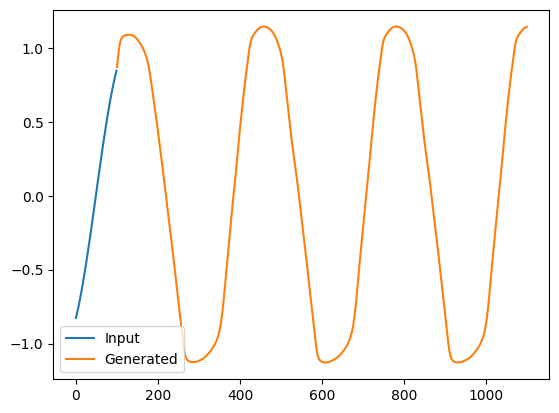

In [182]:
#Visualize...
import matplotlib.pyplot as plt

# original + generated
input_seq = seed.cpu().squeeze().numpy()
pred_seq = predicted.squeeze().numpy()

plt.plot(range(len(input_seq)), input_seq, label="Input")
plt.plot(range(len(input_seq), len(input_seq)+len(pred_seq)), pred_seq, label="Generated")

plt.legend()
plt.show()